# Regressão 01 - tarefa 02 - transformações em X e Y

### 1. Melhorando o ajuste no percentual de gorjetas

a. Vamos partir do modelo feito na última tarefa, o que relaciona ```tip_pct``` e ```net_bill```. Carregue a base, os pacotes e reproduza este modelo aqui.

                            OLS Regression Results                            
Dep. Variable:           perc_gorjeta   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     56.10
Date:                Tue, 26 Nov 2024   Prob (F-statistic):           1.31e-12
Time:                        20:09:39   Log-Likelihood:                 331.48
No. Observations:                 242   AIC:                            -659.0
Df Residuals:                     240   BIC:                            -652.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.2538      0.009     27.252

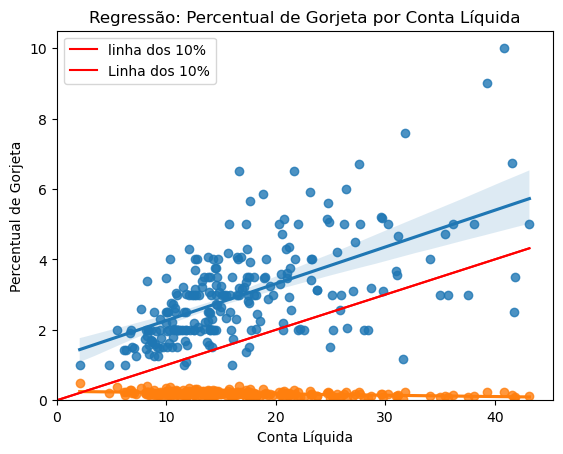

(0.46004042587431093, 0.47783153983492244)

In [6]:
import pandas as pd
import seaborn as sns
from seaborn import load_dataset

import matplotlib.pyplot as plt

import numpy as np

import statsmodels.formula.api as smf

tips = sns.load_dataset("tips")
tips['tip_pct'] = tips['tip'] / (tips['total_bill'] - tips['tip'])
tips['net_bill'] = tips['total_bill'] - tips['tip']
tips.head()

# Gráfico de dispersão
sns.regplot(y = 'tip', x = 'net_bill', data = tips[tips['tip_pct']<.5])

# Gerando dados para a linha dos 10%
x = np.linspace(0,tips['net_bill'].max(),100)
y = .1*x

# Plotando a linha dos 10%
plt.plot(x, y, '-r', label='linha dos 10%')

# Opções estéticas para explicitar o (0,0) no gráfico
plt.xlim(left = 0)
plt.ylim(bottom = 0)

reg = smf.ols('tip ~ net_bill', data = tips).fit()
reg.summary()

dados_novos = tips[0:5]
dados_novos

# Predição de dados novos
reg.predict(dados_novos)

# Onde o Python guarda os parâmetros?
reg.params

# Carregar o dataset
gorjetas = sns.load_dataset("tips")

# Criar novas colunas
gorjetas['perc_gorjeta'] = gorjetas['tip'] / (gorjetas['total_bill'] - gorjetas['tip'])
gorjetas['conta_liquida'] = gorjetas['total_bill'] - gorjetas['tip']

# Filtrar dados para evitar outliers (porcentagem de gorjeta menor que 50%)
dados_filtrados = gorjetas[gorjetas['perc_gorjeta'] < 0.5]

# Gráfico de dispersão
sns.regplot(y='perc_gorjeta', x='conta_liquida', data=dados_filtrados)

# Ajustar modelo de regressão
modelo = smf.ols('perc_gorjeta ~ conta_liquida', data=dados_filtrados).fit()

# Resumo do modelo
print(modelo.summary())

# Adicionar linha de 10% ao gráfico para comparação
x = np.linspace(0, gorjetas['conta_liquida'].max(), 100)
y = 0.1  # Representa uma gorjeta de 10% fixa em relação ao valor líquido
plt.plot(x, y * x, '-r', label='Linha dos 10%')

# Melhorar estética do gráfico
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xlabel('Conta Líquida')
plt.ylabel('Percentual de Gorjeta')
plt.title('Regressão: Percentual de Gorjeta por Conta Líquida')
plt.legend()

# Exibir o gráfico
plt.show()

# Criar manualmente um conjunto de dados similar ao "tips"
dados = {
    "total_bill": [16.99, 10.34, 21.01, 23.68, 24.59],
    "tip": [1.01, 1.66, 3.50, 3.31, 3.61],
    "size": [2, 3, 3, 2, 4]
}

# Criar DataFrame
gorjetas = pd.DataFrame(dados)

# Criar colunas adicionais
gorjetas['perc_gorjeta'] = gorjetas['tip'] / (gorjetas['total_bill'] - gorjetas['tip'])
gorjetas['conta_liquida'] = gorjetas['total_bill'] - gorjetas['tip']

# Ajustar o modelo para perc_gorjeta ~ conta_liquida
modelo_perc = smf.ols('perc_gorjeta ~ conta_liquida', data=gorjetas).fit()

# Obter os valores preditos para perc_gorjeta (tip_pct)
gorjetas['pred_perc_gorjeta'] = modelo_perc.fittedvalues

# Calcular os valores preditos para gorjeta (tip) como perc_gorjeta * conta_liquida
gorjetas['pred_gorjeta'] = gorjetas['pred_perc_gorjeta'] * gorjetas['conta_liquida']

# Calcular o R² do modelo para gorjeta (tip) usando os valores reais e preditos
from sklearn.metrics import r2_score
r2_gorjeta_ajustado = r2_score(gorjetas['tip'], gorjetas['pred_gorjeta'])

# Ajustar o modelo original tip ~ conta_liquida para obter o R² original
modelo_original = smf.ols('tip ~ conta_liquida', data=gorjetas).fit()
r2_gorjeta_original = modelo_original.rsquared

# Exibir os R² ajustado e original
r2_gorjeta_ajustado, r2_gorjeta_original


### 2. ajuste o modelo de ```tip_pct``` em função do logaritmo de ```net_bill```.

In [16]:
# Criar novas colunas
gorjetas['perc_gorjeta'] = gorjetas['tip'] / (gorjetas['total_bill'] - gorjetas['tip'])
gorjetas['conta_liquida'] = gorjetas['total_bill'] - gorjetas['tip']

# Criar coluna logarítmica
gorjetas['log_conta_liquida'] = np.log(gorjetas['conta_liquida'])

# Filtrar dados para evitar outliers (porcentagem de gorjeta menor que 50%)
dados_filtrados = gorjetas[gorjetas['perc_gorjeta'] < 0.5]

# Ajustar modelo de regressão com logaritmo de conta líquida
modelo_log = smf.ols('perc_gorjeta ~ log_conta_liquida', data=dados_filtrados).fit()

# Resumo do modelo
print(modelo_log.summary())

                            OLS Regression Results                            
Dep. Variable:           perc_gorjeta   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                 -0.305
Method:                 Least Squares   F-statistic:                   0.06586
Date:                Tue, 26 Nov 2024   Prob (F-statistic):              0.814
Time:                        20:17:56   Log-Likelihood:                 8.0271
No. Observations:                   5   AIC:                            -12.05
Df Residuals:                       3   BIC:                            -12.84
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.2200      0.24

C:\Users\fabio\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


###  3. ajuste o modelo de ```tip_pct``` em função de um polinômio de segundo grau em ```net_bill```.

In [18]:
# Criar novas colunas
gorjetas['perc_gorjeta'] = gorjetas['tip'] / (gorjetas['total_bill'] - gorjetas['tip'])
gorjetas['conta_liquida'] = gorjetas['total_bill'] - gorjetas['tip']

# Filtrar dados para evitar outliers (porcentagem de gorjeta menor que 50%)
dados_filtrados = gorjetas[gorjetas['perc_gorjeta'] < 0.5]

# Ajustar modelo de regressão com polinômio de segundo grau
modelo_polinomio = smf.ols('perc_gorjeta ~ conta_liquida + I(conta_liquida ** 2)', data=dados_filtrados).fit()

# Resumo do modelo
print(modelo_polinomio.summary())

                            OLS Regression Results                            
Dep. Variable:           perc_gorjeta   R-squared:                       0.310
Model:                            OLS   Adj. R-squared:                 -0.380
Method:                 Least Squares   F-statistic:                    0.4489
Date:                Tue, 26 Nov 2024   Prob (F-statistic):              0.690
Time:                        20:20:34   Log-Likelihood:                 8.8998
No. Observations:                   5   AIC:                            -11.80
Df Residuals:                       2   BIC:                            -12.97
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.50

C:\Users\fabio\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


###  4. ajuste um modelo no log do ```tip_pct``` em função de ```net_bill```. Calcule o $R^2$ também em ```tip_pct```

In [20]:
# Criar novas colunas
gorjetas['tip_pct'] = gorjetas['tip'] / gorjetas['total_bill']
gorjetas['conta_liquida'] = gorjetas['total_bill'] - gorjetas['tip']

# Filtrar dados para evitar outliers (porcentagem de gorjeta menor que 50%)
dados_filtrados = gorjetas[gorjetas['tip_pct'] < 0.5]

# Ajustar modelo de regressão no log de tip_pct
modelo_log = smf.ols('np.log(tip_pct) ~ conta_liquida', data=dados_filtrados).fit()

# Resumo do modelo
print(modelo_log.summary())

# Calcular R² para tip_pct
r_squared = modelo_log.rsquared
print(f'R² para log(tip_pct): {r_squared}')

                            OLS Regression Results                            
Dep. Variable:        np.log(tip_pct)   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.333
Method:                 Least Squares   F-statistic:                 0.0008344
Date:                Tue, 26 Nov 2024   Prob (F-statistic):              0.979
Time:                        20:21:08   Log-Likelihood:                -2.3006
No. Observations:                   5   AIC:                             8.601
Df Residuals:                       3   BIC:                             7.820
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -2.0419      0.867     -2.355

C:\Users\fabio\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


###  5. ajuste um modelo no log do ```tip_pct``` em função do log de ```net_bill```. Calcule o $R^2$ também em ```tip_pct```.

In [22]:
# Filtrar dados para evitar outliers (porcentagem de gorjeta menor que 50%)
dados_filtrados = gorjetas[gorjetas['tip_pct'] < 0.5]

# Criar a coluna logarítmica da conta líquida
dados_filtrados['log_conta_liquida'] = np.log(dados_filtrados['conta_liquida'])

# Ajustar modelo de regressão no log de tip_pct em função do log de conta líquida
modelo_log = smf.ols('np.log(tip_pct) ~ log_conta_liquida', data=dados_filtrados).fit()

# Resumo do modelo
print(modelo_log.summary())

# Calcular R² para tip_pct
r_squared = modelo_log.rsquared
print(f'R² para log(tip_pct): {r_squared}')

                            OLS Regression Results                            
Dep. Variable:        np.log(tip_pct)   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.322
Method:                 Least Squares   F-statistic:                   0.02468
Date:                Tue, 26 Nov 2024   Prob (F-statistic):              0.885
Time:                        20:22:34   Log-Likelihood:                -2.2808
No. Observations:                   5   AIC:                             8.562
Df Residuals:                       3   BIC:                             7.780
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -1.7668      1.91

C:\Users\fabio\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


###  6. qual modelo resultou no melhor ajuste?

O R² do modelo 3 foi o maior, isso sugere que a relação entre tip_pct e net_bill é mais bem capturada pela transformação logarítmica.